In [1]:
# dependencies
import pandas as pd
import numpy as np
from pupeyes import PupilProcessor, EyelinkReader

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# file name
path = 'example_data/sub001.asc'

# event marker format, specified as a dictionary {name: data type}   
msg_format = {'marker':str, 'event':str, 'block':str, 'trial':int} # e.g., start retention A 4
delimiter = ' ' # delimiter for messages

# start and stop notations for each trial
start_msg = 'start fixation'
stop_msg = 'end feedback'

# If you have any constant columns that you want to add
add_cols = {'subject':'003', 'condition': 'low'}

# Read data
raw = EyelinkReader(path=path, start_msg=start_msg, stop_msg=stop_msg, msg_format=msg_format, delimiter=delimiter, add_cols=add_cols)

Reading ASC file example_data/sub001.asc: 100%|██████████| 172262/172262 [00:00<00:00, 307149.53it/s]


In [4]:
raw_samples = raw.get_samples()
raw_samples.head()

,trialtime,trackertime,x,y,pp,msg,msgtime,marker,event,block,trial,subject,condition
0,0,3148741,856.9,424.4,5545,start fixation A 1,3148741,start,fixation,A,1,003,low
1,1,3148742,857.5,425.9,5546,start fixation A 1,3148741,start,fixation,A,1,003,low
2,2,3148743,858.0,427.2,5547,start fixation A 1,3148741,start,fixation,A,1,003,low
3,3,3148744,858.2,427.2,5547,start fixation A 1,3148741,start,fixation,A,1,003,low
4,4,3148745,857.9,427.1,5545,start fixation A 1,3148741,start,fixation,A,1,003,low


In [5]:
samp = raw_samples.copy()
samp = samp[samp.event.isin(['fixation', 'stimulus']) & samp.block.isin(['A', 'B', 'C', 'D', 'E'])].reset_index(drop=True)

In [6]:
p = PupilProcessor(
    data=samp, 
    trial_identifier=['subject', 'block', 'trial'], 
    #trial_identifier='trialid',
    x_col = 'x',
    y_col = 'y',
    pupil_col = 'pp',
    time_col = 'trialtime',
    samp_freq = 1000,
    convert_pupil_size=True)
    
p = p.deblink().artifact_rejection().filter_position().smooth().interpolate(missing_threshold=0.5).baseline_correction(baseline_query='routine=="baseline"', baseline_range=[-100, None])

Sampling frequency check passed.
Pupil data converted to diameter with artificial d=5 and artificial size=5663
PupilProcessor initialized with 39993 samples
Pupil column: pp, Time column: trialtime, X column: x, Y column: y
Trial identifier: ['subject', 'block', 'trial'], Number of trials: 10


Artifact rejection: 100%|██████████| 10/10 [00:00<00:00, 118.47it/s]


TypeError: PupilProcessor.filter_position() missing 1 required positional argument: 'vertices'

In [ ]:
trial = {'block':'B', 'trial':2}
p.plot_trial(
		trial=trial,
		x='trialtime',
		y=p.all_pupil_cols,
		hue='routine', 
		#save = 'trial.pdf',
		interactive=True,
		plot_params={'layout':(4,2), 'x_title':'Time (ms)', 'y_title':'Pupil Size'})

In [ ]:
from pupeyes import PupilViewer

# Assuming you have a PupilProcessor instance called 'p'
viewer = PupilViewer(p)
viewer.run_server(debug=True)

# Diagnostics


In [ ]:
p.check_baseline_outliers(n_mad_baseline=5, outlier_by=['subject','block'], save='baseline.html')

In [ ]:
p.plot_baseline(plot_by=['block'], show_outliers=True, save='baseline.html')

In [ ]:
p.check_trace_outliers(y='pp_db_ar_xy_sm_it', outlier_by='block')

In [24]:
p.plot_spaghetti(y='pp_db_ar_xy_sm_it', plot_by=['subject','block'], show_outliers=True)

/Users/HanZhang/Documents/GitHub/pupeyes/src/pupeyes/pupil.py:1863: UserWarning:

Outlier detection was performed by ['block']. Plotting by ['subject', 'block']. The plotted thresholds may be incorrect.



In [25]:
# plot a problematic trial according to the summary data
bad_trials = p.summary().query('run_deblink==False | run_speed==False | run_size==False | run_position==False | run_smooth==False | run_interpolate==False | run_baseline_correction==False | baseline_outlier==True | trace_outlier==True')[['subject','block','trial']]
bad_trials

,subject,block,trial
6,003,A,7
7,003,A,8
10,003,B,1


In [45]:
more_bad_trials = pd.DataFrame([
    {'subject':'003', 'block':'A', 'trial':18},
    {'subject':'003', 'block':'A', 'trial':20},
    {'subject':'003', 'block':'E', 'trial':18},
    {'subject':'003', 'block':'E', 'trial':14},
    {'subject':'003', 'block':'E', 'trial':11},

    ])

p.all_bad_trials = pd.concat([bad_trials, more_bad_trials])
p.all_bad_trials

,subject,block,trial
6,003,A,7
7,003,A,8
17,003,A,18
30,003,B,1
60,003,C,1
67,003,C,8
73,003,C,14
90,003,D,1
103,003,D,14
105,003,D,16


In [46]:
p = p.validate_trials(p.all_bad_trials)

In [47]:
# designed to help but not confine
p.final_data = p.data.query('valid==True & routine=="trial_stim"').reset_index(drop=True)
p.final_data['pp_final'] = p.final_data['pp_db_ar_xy_sm_it_bc']
p.final_data.head()

,trialtime,trackertime,x,y,pp,msg,msgtime,event,routine,block,...,subject,trialid,pp_db,pp_db_ar,pp_db_ar_xy,pp_db_ar_xy_sm,pp_db_ar_xy_sm_it,pp_db_ar_xy_sm_it_bc,valid,pp_final
0,984,3149725,957.8,490.3,4.863147,start trial_stim A 1,3149725,start,trial_stim,A,...,003,003_A_1,4.863147,4.863147,4.863147,4.866553,4.866553,0.009172,True,0.009172
1,985,3149726,957.9,489.3,4.865796,start trial_stim A 1,3149725,start,trial_stim,A,...,003,003_A_1,4.865796,4.865796,4.865796,4.866945,4.866945,0.009564,True,0.009564
2,986,3149727,958.0,488.5,4.87021,start trial_stim A 1,3149725,start,trial_stim,A,...,003,003_A_1,4.87021,4.87021,4.87021,4.867328,4.867328,0.009948,True,0.009948
3,987,3149728,958.1,488.3,4.873742,start trial_stim A 1,3149725,start,trial_stim,A,...,003,003_A_1,4.873742,4.873742,4.873742,4.867703,4.867703,0.010323,True,0.010323
4,988,3149729,958.0,488.8,4.874625,start trial_stim A 1,3149725,start,trial_stim,A,...,003,003_A_1,4.874625,4.874625,4.874625,4.86807,4.86807,0.010689,True,0.010689


In [48]:
p.save('mysubject.pkl')

In [49]:
# p2=PupilProcessor.load('mysubject.pkl')

In [50]:
# p3 = PupilProcessor(data=samp, trial_identifier=['subject', 'block', 'trial'])

# p3.copy().deblink()

# Statistical tests


In [26]:
import mne.stats as ms

ModuleNotFoundError: No module named 'mne'

127 trials. Minimum number of samples: 2996. Data will be padded to size: 127 x 2996


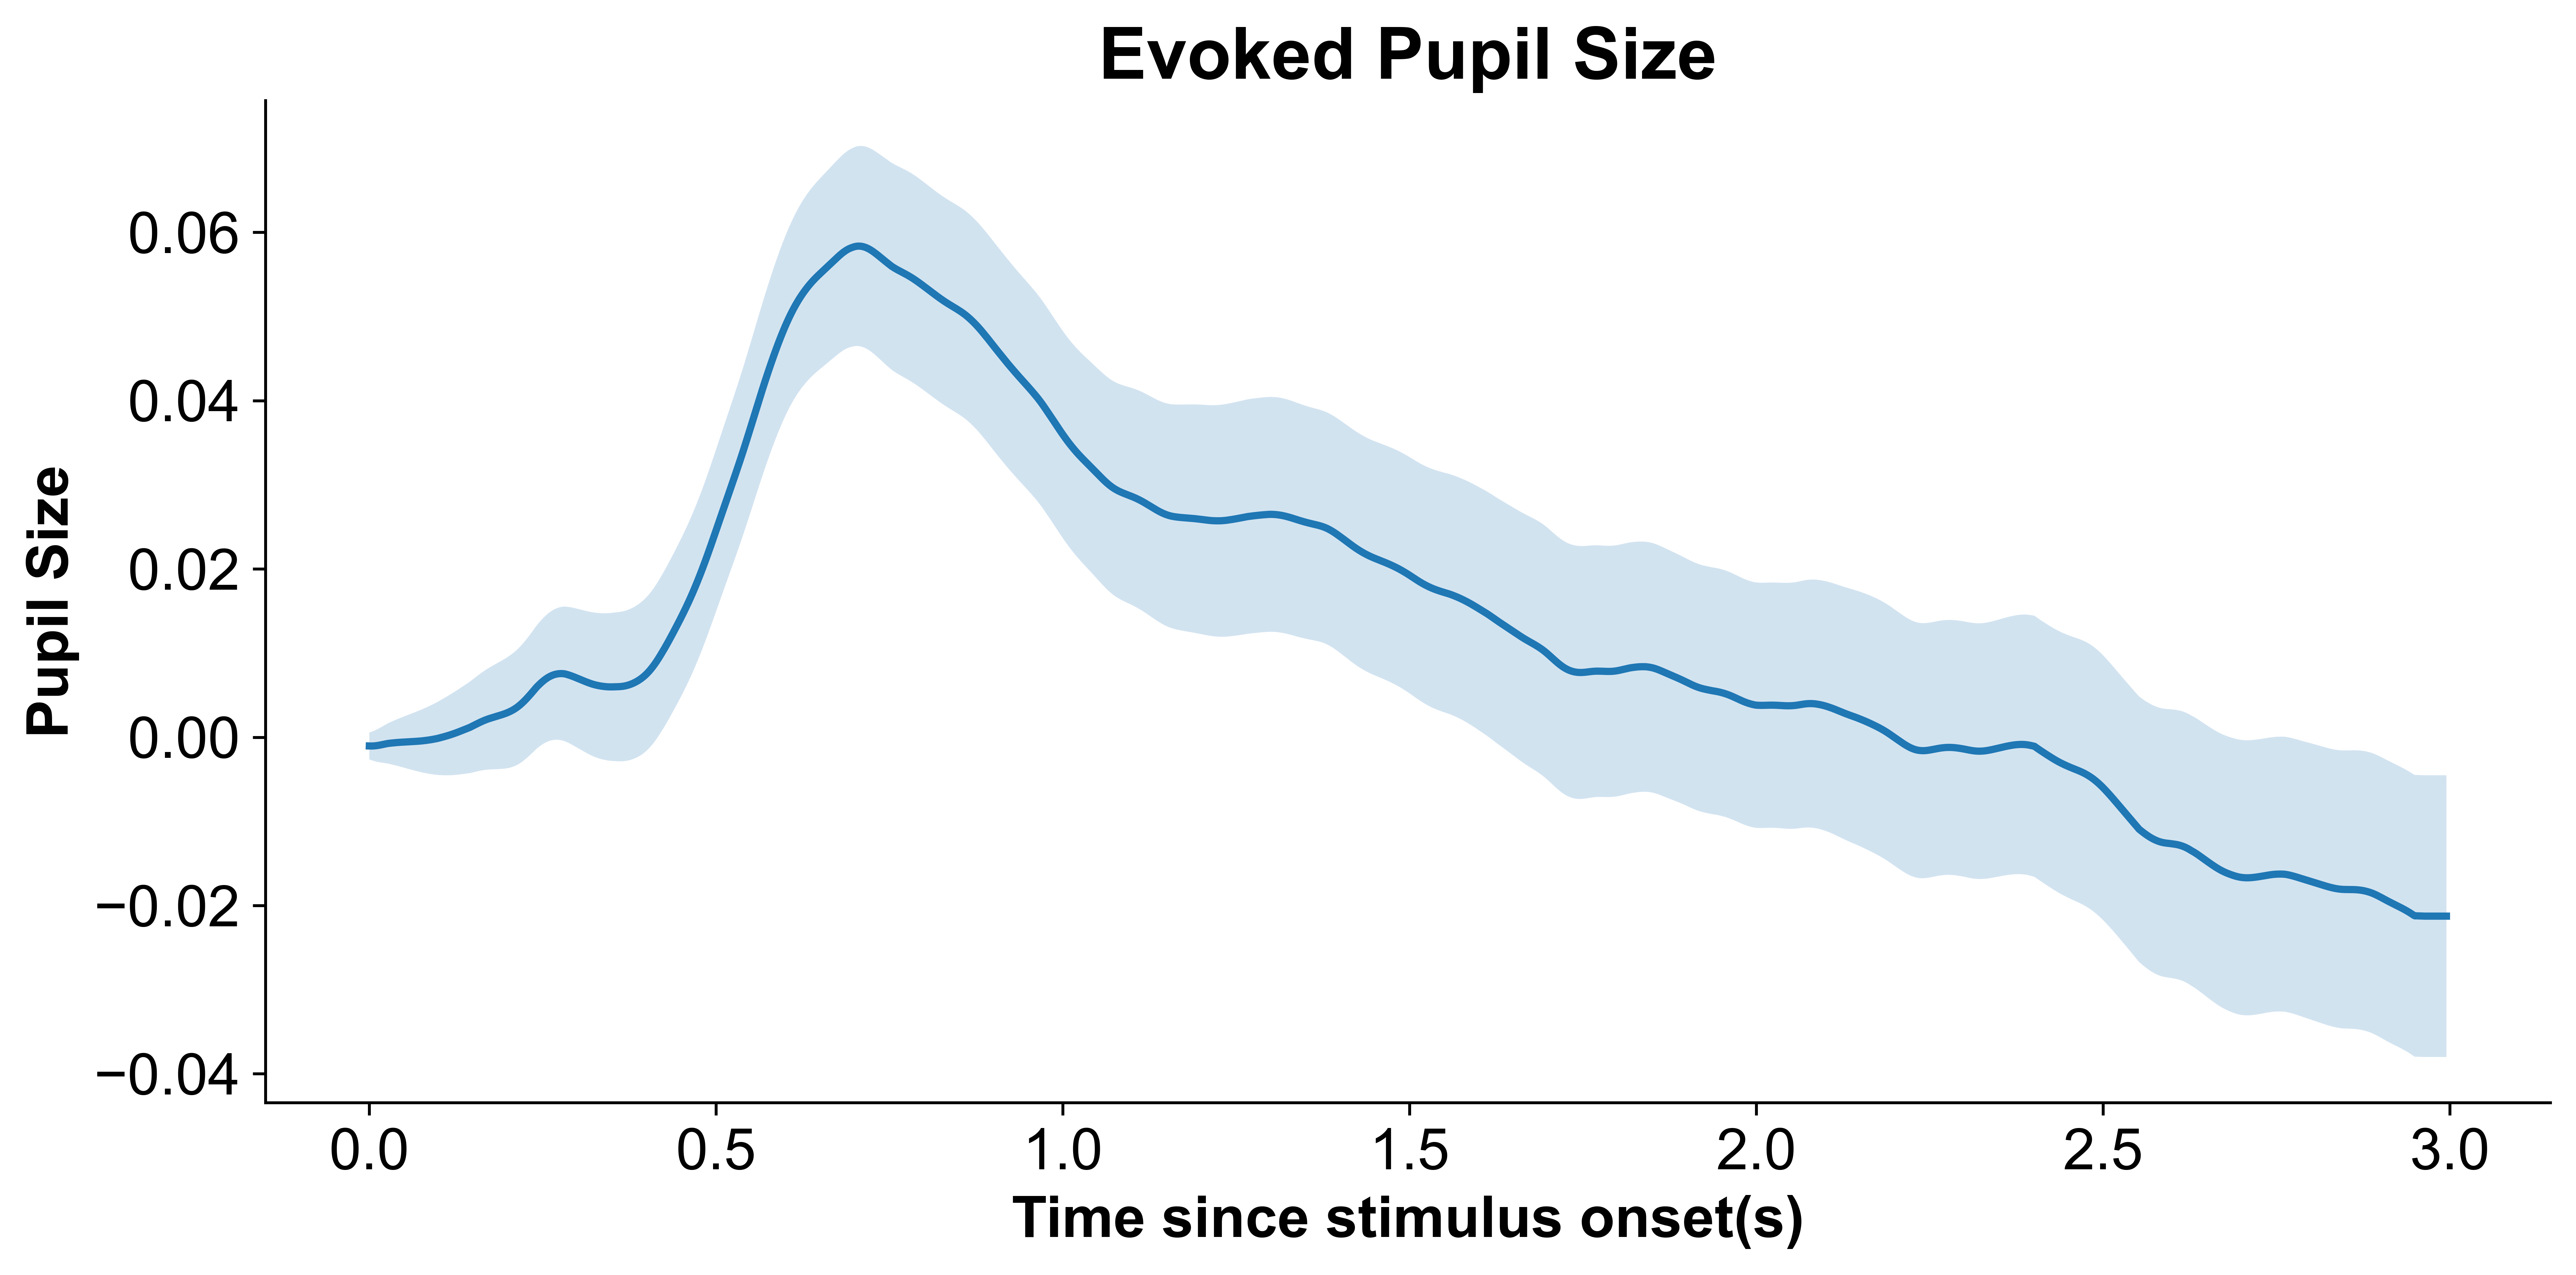

In [81]:
test_array, (fig, ax) = p.plot_evoked(data='final_data', pupil_col='pp_final', error='sem')

In [53]:
p.test_array = test_array

In [54]:
ar = test_array['all']
ar.shape

(127, 2996)

In [55]:
ci_low, ci_high = ms.bootstrap_confidence_interval(ar)

In [56]:
T_obs, clusters, cluster_p_values, H0 = ms.permutation_cluster_1samp_test(
    ar,
    n_permutations=1000,
    tail=0,
    n_jobs=-1,
    out_type="mask",
)

Using a threshold of 1.978971
stat_fun(H1): min=-1.2653334482437586 max=4.927300375421641
Running initial clustering …
Found 1 cluster


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

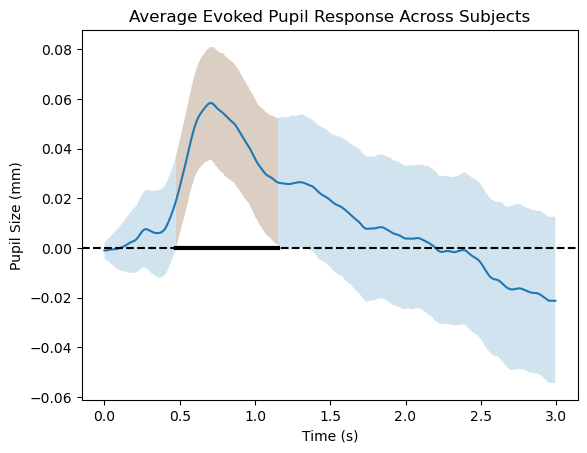

In [57]:
import matplotlib.pyplot as plt

# plot data and visualize clusters
fig, ax = plt.subplots()

t = np.arange(ar.shape[1]) / 1000
ax.plot(t, ar.mean(axis=0))
ax.fill_between(t, ci_low, ci_high, alpha=0.2)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Pupil Size (mm)')
ax.set_title('Average Evoked Pupil Response Across Subjects')

# plot clusters
for cluster in clusters:
    ax.fill_between(t[cluster], ci_low[cluster], ci_high[cluster], alpha=0.2)
    ax.plot(t[cluster], 0*np.ones(len(t[cluster])), color='black', linewidth=3)

# baseline
ax.axhline(0, color='black', linestyle='--')


In [58]:
ar2 = ar.copy()
ar2 = ar2*3

In [59]:
ci_low_ar, ci_high_ar = ms.bootstrap_confidence_interval(ar)
ci_low_ar2, ci_high_ar2 = ms.bootstrap_confidence_interval(ar2)

In [60]:
T_obs, clusters, cluster_p_values, H0 = ms.permutation_cluster_test(
    [ar, ar2],
    n_permutations=1000,
    n_jobs=-1,
    out_type="mask",
)

Using a threshold of 3.878624
stat_fun(H1): min=1.8577997250512067e-09 max=9.711315595852124
Running initial clustering …
Found 1 cluster


C:\Users\Hans Cheng\AppData\Local\Temp\ipykernel_9128\2406134511.py:1: RuntimeWarning:

Ignoring argument "tail", performing 1-tailed F-test



  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

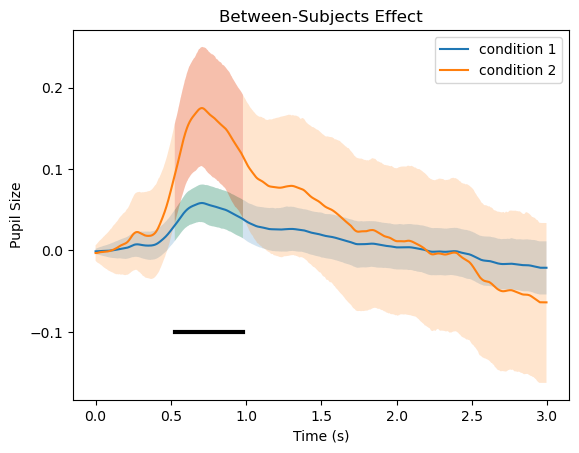

In [61]:
# plot data and visualize clusters
fig, ax = plt.subplots()

t = np.arange(ar.shape[1]) / 1000
ax.plot(t, ar.mean(axis=0), label='condition 1')
ax.plot(t, ar2.mean(axis=0), label='condition 2')

ax.fill_between(t, ci_low_ar, ci_high_ar, alpha=0.2)
ax.fill_between(t, ci_low_ar2, ci_high_ar2, alpha=0.2)

# plot clusters
for cluster in clusters:
    ax.plot(t[cluster], -.1*np.ones(len(t[cluster])), color='black', linewidth=3)
    ax.fill_between(t[cluster], ci_low_ar[cluster], ci_high_ar[cluster], alpha=0.2)
    ax.fill_between(t[cluster], ci_low_ar2[cluster], ci_high_ar2[cluster], alpha=0.2)


ax.set_xlabel('Time (s)')
ax.set_ylabel('Pupil Size')
ax.set_title('Between-Subjects Effect')
ax.legend()
